# LTR terminal:internal deletion-footprint analysis

**All vetted genomic resources with eligible LTR elements (LTR30), not path18**

This is a collaborator-review notebook. It loads frozen data, figures, manifests,
and trees and can link to optional local HTML review pages; it does not rerun
expensive bioinformatics, segmentation, model training, or path-model fitting.
Every result is identified by its analysis panel and exact source path.

In [1]:
from pathlib import Path
import hashlib
import json

import numpy as np
import pandas as pd
from IPython.display import HTML, IFrame, Image, Markdown, display

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "path_analysis/data/derived").exists() and (candidate / "scripts/processing").exists():
        ROOT = candidate
        break
else:
    raise RuntimeError("Open this notebook from inside the Desmognathus_TE repository")

REVIEW_FIGURE_DIR = ROOT / "results/figures/research_review"
REVIEW_DATA_DIR = ROOT / "results/data/research_review"
FROZEN_INPUT_DIR = REVIEW_DATA_DIR / "frozen_inputs"
FROZEN_REGISTRY_PATH = REVIEW_DATA_DIR / "frozen_input_registry.csv"
FIGURE_BUILD_COMMAND = 'scripts/run_in_dusky.sh Rscript scripts/processing/build_audited_historical_style_figures.R'

if not FROZEN_REGISTRY_PATH.exists():
    raise FileNotFoundError(
        f"Portable dependency registry missing: {FROZEN_REGISTRY_PATH}. "
        "Rebuild the research-review notebooks first."
    )
frozen_registry = pd.read_csv(FROZEN_REGISTRY_PATH)
required_registry_columns = {"source_path", "frozen_path", "source_sha256", "frozen_sha256"}
if not required_registry_columns.issubset(frozen_registry.columns):
    raise RuntimeError("Frozen dependency registry schema is incomplete")
if not frozen_registry.source_sha256.eq(frozen_registry.frozen_sha256).all():
    raise RuntimeError("Frozen dependency registry contains a source/snapshot hash mismatch")
FROZEN_ARTIFACTS = dict(zip(frozen_registry.source_path, frozen_registry.frozen_path))

def file_sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

missing_snapshots = [path for path in frozen_registry.frozen_path if not (ROOT / path).exists()]
if missing_snapshots:
    raise FileNotFoundError(f"Portable dependency snapshots missing: {missing_snapshots}")
corrupt_snapshots = [
    row.frozen_path
    for row in frozen_registry.itertuples()
    if file_sha256(ROOT / row.frozen_path) != row.frozen_sha256
]
if corrupt_snapshots:
    raise RuntimeError(f"Portable dependency snapshot SHA256 mismatch: {corrupt_snapshots}")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 120)
pd.set_option("display.max_colwidth", 120)

def resolve_artifact(relative):
    path = Path(relative)
    if path.is_absolute():
        return path
    return ROOT / FROZEN_ARTIFACTS.get(str(relative), str(relative))

def read_csv(relative, **kwargs):
    path = resolve_artifact(relative)
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path, **kwargs)

def require_paths(paths, build_command=None):
    missing = [str(path) for path in paths if not Path(path).exists()]
    if missing:
        message = "Missing required frozen review artifacts:\n- " + "\n- ".join(missing)
        if build_command:
            message += f"\n\nGenerate only the lightweight review outputs with:\n{build_command}"
        raise FileNotFoundError(message)

def show_figure(relative, width=1150):
    path = resolve_artifact(relative)
    require_paths([path])
    display(Image(filename=str(path), width=width))

def show_text(relative, language="text", max_chars=16000):
    path = resolve_artifact(relative)
    require_paths([path])
    text = path.read_text(errors="replace")
    if len(text) > max_chars:
        text = text[:max_chars] + "\n... [display truncated; open the linked source for the complete file]"
    display(Markdown(f"```{language}\n{text}\n```"))

def artifact_table(relatives):
    rows = []
    for relative in relatives:
        path = resolve_artifact(relative)
        rows.append({
            "artifact": relative,
            "frozen_artifact": str(path.relative_to(ROOT)),
            "exists": path.exists(),
            "size_mb": round(path.stat().st_size / 1024**2, 3) if path.exists() else np.nan,
        })
    result = pd.DataFrame(rows)
    if not result.exists.all():
        raise FileNotFoundError(result.loc[~result.exists, "artifact"].tolist())
    return result

print(f"Repository: {ROOT}")
print("Mode: frozen-artifact review only; no expensive upstream analysis is run")
print(f"Portable dependency snapshots: {len(frozen_registry)}")

Repository: /home/jake/Projects/Desmognathus_TE
Mode: frozen-artifact review only; no expensive upstream analysis is run
Portable dependency snapshots: 90


## Estimand and denominator

The element-level value is terminal-LTR read depth divided by internal-region read
depth for structurally annotated LTR elements. It is a deletion-footprint and
mapping proxy—not a direct solo-LTR count, an orthologous deletion event, or an
ectopic-recombination rate. The descriptive panel includes every vetted species
with eligible data; it is not reduced to the TE/cell path18 intersection.

The primary ratio includes every expected terminal and internal position, retaining
explicit zero-depth positions. The corrected branch contains **1,086 usable elements
across 30 species**. Two of the original 1,088 selected elements are excluded because
their depth files end in truncated partial lines; both exclusions are preserved in
the source audit. The old 1,088-element nonzero-only table is retained solely for
numerical comparison and is not a primary analysis input.

The violin is regenerated from audited current data using historical R code/style.
No historical PDF/PNG raster is presented as a current result.

In [2]:
expected = [
        REVIEW_FIGURE_DIR / "ltr_terminal_internal_artifact_screened_ltr30_v1.png",
        REVIEW_FIGURE_DIR / "ltr_terminal_internal_violin_ltr30_v1.png",
        REVIEW_FIGURE_DIR / "ltr_terminal_internal_log_ltr30_v1.png",
        REVIEW_FIGURE_DIR / "ectopic_ltr30_coverage_qc_v1.png",
        REVIEW_DATA_DIR / "ltr_mapping_artifact_screen_ltr30_v1.csv",
    REVIEW_DATA_DIR / "ltr_terminal_internal_stats_v1.txt",
    REVIEW_DATA_DIR / "audited_historical_style_figures_v1.manifest.json",
    resolve_artifact("results/data/corrected/ectopic_ltr30/ectopic_element_metrics_ltr30_v1.csv"),
    resolve_artifact("results/data/corrected/ectopic_ltr30/ectopic_species_robustness_ltr30_v1.csv"),
    resolve_artifact("results/data/corrected/ectopic_ltr30/ectopic_excluded_elements_ltr30_v1.csv"),
    resolve_artifact("results/data/corrected/ectopic_ltr30/ectopic_resource_coverage_ltr30_v1.csv"),
    resolve_artifact("results/data/corrected/ectopic_ltr30/ectopic_ltr30_v1.manifest.json"),
]
require_paths(expected, build_command=FIGURE_BUILD_COMMAND)

## Exact R source and element-level input

In [3]:
source_files = pd.DataFrame([{'role': 'current R review runner', 'path': 'scripts/processing/build_audited_historical_style_figures.R'}, {'role': 'corrected zero-aware LTR30 builder', 'path': 'scripts/processing/build_corrected_ectopic_ltr30.py'}, {'role': 'preserved historical LTR adapter', 'path': 'scripts/processing/restore_talk_iv_ectopic_from_historical_r.R'}, {'role': 'corrected all-position element input', 'path': 'results/data/corrected/ectopic_ltr30/ectopic_element_metrics_ltr30_v1.csv'}, {'role': 'species robustness', 'path': 'results/data/corrected/ectopic_ltr30/ectopic_species_robustness_ltr30_v1.csv'}, {'role': 'source-corrupt exclusions', 'path': 'results/data/corrected/ectopic_ltr30/ectopic_excluded_elements_ltr30_v1.csv'}, {'role': 'resource coverage audit', 'path': 'results/data/corrected/ectopic_ltr30/ectopic_resource_coverage_ltr30_v1.csv'}, {'role': 'corrected LTR30 manifest', 'path': 'results/data/corrected/ectopic_ltr30/ectopic_ltr30_v1.manifest.json'}, {'role': 'vetted genomic panel', 'path': 'path_analysis/data/derived/panels/study_te_resource_panel34_v1.csv'}, {'role': 'statistics', 'path': 'results/data/research_review/ltr_terminal_internal_stats_v1.txt'}])
source_files["resolved_path"] = source_files.path.map(lambda value: str(resolve_artifact(value).relative_to(ROOT)))
source_files["exists"] = source_files.path.map(lambda value: resolve_artifact(value).exists())
display(source_files)
if not source_files.exists.all():
    raise FileNotFoundError(source_files.loc[~source_files.exists, "path"].tolist())

show_text('scripts/processing/build_audited_historical_style_figures.R', language='r')

,role,path,resolved_path,exists
0,current R review runner,scripts/processing/build_audited_historical_style_figures.R,scripts/processing/build_audited_historical_style_figures.R,True
1,corrected zero-aware LTR30 builder,scripts/processing/build_corrected_ectopic_ltr30.py,scripts/processing/build_corrected_ectopic_ltr30.py,True
2,preserved historical LTR adapter,scripts/processing/restore_talk_iv_ectopic_from_historical_r.R,scripts/processing/restore_talk_iv_ectopic_from_historical_r.R,True
3,corrected all-position element input,results/data/corrected/ectopic_ltr30/ectopic_element_metrics_ltr30_v1.csv,results/data/research_review/frozen_inputs/results/data/corrected/ectopic_ltr30/ectopic_element_metrics_ltr30_v1.csv,True
4,species robustness,results/data/corrected/ectopic_ltr30/ectopic_species_robustness_ltr30_v1.csv,results/data/research_review/frozen_inputs/results/data/corrected/ectopic_ltr30/ectopic_species_robustness_ltr30_v1.csv,True
5,source-corrupt exclusions,results/data/corrected/ectopic_ltr30/ectopic_excluded_elements_ltr30_v1.csv,results/data/research_review/frozen_inputs/results/data/corrected/ectopic_ltr30/ectopic_excluded_elements_ltr30_v1.csv,True
6,resource coverage audit,results/data/corrected/ectopic_ltr30/ectopic_resource_coverage_ltr30_v1.csv,results/data/research_review/frozen_inputs/results/data/corrected/ectopic_ltr30/ectopic_resource_coverage_ltr30_v1.csv,True
7,corrected LTR30 manifest,results/data/corrected/ectopic_ltr30/ectopic_ltr30_v1.manifest.json,results/data/research_review/frozen_inputs/results/data/corrected/ectopic_ltr30/ectopic_ltr30_v1.manifest.json,True
8,vetted genomic panel,path_analysis/data/derived/panels/study_te_resource_panel34_v1.csv,results/data/research_review/frozen_inputs/path_analysis/data/derived/panels/study_te_resource_panel34_v1.csv,True
9,statistics,results/data/research_review/ltr_terminal_internal_stats_v1.txt,results/data/research_review/ltr_terminal_internal_stats_v1.txt,True


```r
#!/usr/bin/env Rscript

# Rebuild Jake's historical R/ggplot figure suite on the frozen, audited data.
#
# This script deliberately does NOT embed or copy historical PNGs and does not
# execute dnaPipeTE, RepeatMasker, RepeatModeler, read mapping, or LTR discovery.
# The historical plotting grammar is recovered from:
#   /home/jake/Projects/misc_desmog_scripts/Master_data_vis.R
#   Git 1ad5e8c:te_pca_analysis.R
#   Git 1ad5e8c:scripts/visualization/te_landscape_plots.R
#   Git 1ad5e8c:scripts/visualization/ectopic_recomb_plots.R
#   VS Code history DWDT.R / Git 89c0879:Master_data_vis_PCA.R
#   Git 89c0879:Master_data_vis2_ectopicrecomb.R

options(stringsAsFactors = FALSE)

args <- commandArgs(trailingOnly = FALSE)
script_flag <- grep("^--file=", args, value = TRUE)
script_dir <- if (length(script_flag)) {
  dirname(normalizePath(sub("^--file=", "", script_flag[[1]]), mustWork = FALSE))
} else {
  "scripts/processing"
}
root <- normalizePath(file.path(script_dir, "..", ".."), mustWork = TRUE)

suppressPackageStartupMessages({
  library(ape)
  library(cluster)
  library(dplyr)
  library(ggplot2)
  library(ggrepel)
  library(ggtree)
  library(jsonlite)
  library(nlme)
  library(patchwork)
  library(readr)
  library(scales)
  library(tidyr)
  library(viridis)
})

SEED <- 20260710L
CONFIGURED_QUANTIFICATION_SAMPLE_BP <- 1500000000

data_out <- file.path(root, "results", "data", "research_review")
figure_out <- file.path(root, "results", "figures", "research_review")
frozen_input_root <- file.path(data_out, "frozen_inputs")
dir.create(data_out, recursive = TRUE, showWarnings = FALSE)
dir.create(figure_out, recursive = TRUE, showWarnings = FALSE)

WANG_JI_SOURCE_SHA256 <- "4ec3237a6ecd361c7e040b11dccfc9e2ac635cf10b739a4e95920015edccbb0e"
WANG_JI_DOI <- "10.1038/s42003-025-08127-3"
WANG_JI_DRYAD_DOI <- "10.5061/dryad.zpc866tkv"
wang_ji_local_source <- "/home/jake/Projects/Desmognathus_Results/wang_ji_shannondiversity.csv"
wang_ji_snapshot <- file.path(data_out, "wang_ji_2025_shannon_context_v1.csv")
wang_ji_provenance <- file.path(data_out, "wang_ji_2025_shannon_context_v1.provenance.json")

paths <- list(
  panel = file.path(frozen_input_root, "path_analysis", "data", "derived", "panels", "study_te_resource_panel34_v1.csv"),
  integrated_panel = file.path(frozen_input_root, "path_analysis", "data", "derived", "panels", "study_integrated_path_panel18_v1.csv"),
  genome_estimates = file.path(frozen_input_root, "path_analysis", "data", "external", "derived", "cellprofiler_final_species_results.csv"),
  genome_state = file.path(frozen_input_root, "path_analysis", "data", "external", "derived", "cellprofiler_genome_state_summary.csv"),
  retry_manifest = file.path(frozen_input_root, "results", "data", "corrected", "te34_replicate_averaged", "te34_replicate_averaged_v1.manifest.json"),
  mass = file.path(frozen_input_root, "results", "data", "corrected", "te34_replicate_averaged", "dnapipete_mass_accounting_te34_replicate_averaged_v1.csv"),
  quality = file.path(frozen_input_root, "results", "data", "legacy_descriptive", "dnapipete_species_quality_te34_legacy_descriptive_v1.csv"),
  order_composition = file.path(frozen_input_root, "results", "data", "legacy_descriptive", "te_order_composition_te34_legacy_descriptive_v1.csv"),
  superfamily_composition = file.path(frozen_input_root, "results", "data", "legacy_descriptive", "te_superfamily_composition_te34_legacy_descriptive_v1.csv"),
  diversity = file.path(frozen_input_root, "results", "data", "corrected", "te34_replicate_averaged", "te_diversity_mass_sensitivity_te34_replicate_averaged_v1.csv"),
  wang_ji_context = wang_ji_snapshot,
  wang_ji_provenance = wang_ji_provenance,
  ltr_elements = file.path(frozen_input_root, "results", "data", "corrected", "ectopic_ltr30", "ectopic_element_metrics_ltr30_v1.csv"),
  ltr_exclusions = file.path(frozen_input_root, "results", "data", "corrected", "ectopic_ltr30", "ectopic_excluded_elements_ltr30_v1.csv"),
  ltr_manifest = file.path(frozen_input_root, "results", "data", "corrected", "ectopic_ltr30", "ectopic_ltr30_v1.manifest.json"),
  tree = file.path(frozen_input_root, "results", "phylogeny", "processed_phylogeny.nwk")
)

missing_inputs <- setdiff(
  names(paths)[!file.exists(unlist(paths))],
  c("wang_ji_context", "wang_ji_provenance")
)
if (length(missing_inputs)) {
  stop("Missing required frozen input(s): ", paste(missing_inputs, collapse = ", "))
}

canonical_species <- function(value) {
  value <- tolower(trimws(as.character(value)))
  value <- sub("^desmognathus\\s+", "", value)
  value <- sub("^d\\.\\s*", "", value)
  value
}

display_species <- function(value) paste0("D. ", canonical_species(value))

assert_columns <- function(data, required, label) {
  absent <- setdiff(required, names(data))
  if (length(absent)) stop(label, " lacks required column(s): ", paste(absent, collapse = ", "))
}

assert_te34 <- function(data, label) {
  species <- sort(unique(canonical_species(data$species)))
  if (length(species) != 34L || !identical(species, panel_species)) {
    stop(label, " must contain the exact 34-species audited TE-resource panel")
  }
}

sha256 <- function(path) {
  result <- system2("sha256sum", path, stdout = TRUE, stderr = TRUE)
  if (!length(result) || !grepl("^[0-9a-f]{64}", result[[1]])) {
    stop("Could not calculate SHA256 for ", path)
  }
  sub("\\s+.*$", "", result[[1]])
}

if (!file.exists(wang_ji_snapshot) || !file.exists(wang_ji_provenance)) {
  if (!file.exists(wang_ji_local_source)) {
    stop(
      "Missing the portable Wang et al. snapshot and its hash-locked local source: ",
      wang_ji_local_source
    )
  }
  source_sha256 <- sha256(wang_ji_local_source)
  if (!identical(source_sha256, WANG_JI_SOURCE_SHA256)) {
    stop("Wang et al. historical composite no longer matches its audited SHA256")
  }
  wang_raw <- read_csv(wang_ji_local_source, show_col_types = FALSE, name_repair = "minimal")
  names(wang_raw) <- trimws(names(wang_raw))
  wang_raw <- wang_raw %>% mutate(across(where(is.character), trimws))
  assert_columns(wang_raw, c("English_name", "species", "Family", "GS", "SI", "GSI", "Type"), "Wang et al. context")
  wang_clean <- wang_raw %>%
    transmute(
      source_row = row_number(),
      english_name = English_name,
      species = species,
      family = Family,
      genome_size_gb = as.numeric(GS),
      shannon_top10_superfamilies = as.numeric(SI),
      gini_simpson_top10_superfamilies = as.numeric(GSI),
      group = Type,
      source = "Historical published-vertebrate composite used by prior project code"
    )
  if (nrow(wang_clean) != 87L || anyNA(wang_clean)) {
    stop("Cleaned Wang et al. historical composite must contain 87 complete rows")
  }
  write_csv(wang_clean, wang_ji_snapshot)
  write_json(
    list(
      artifact_id = "wang_ji_2025_shannon_context_v1",
      local_source_path = wang_ji_local_source,
      local_source_sha256 = source_sha256,
      local_source_rows = 87L,
      cleaning = "Whitespace-only header/value cleanup and explicit typed column names; published values unchanged.",
      context_reference = paste0("Wang et al. 2025, Communications Biology, DOI ", WANG_JI_DOI),
      published_data_repository = paste0("Dryad DOI ", WANG_JI_DRYAD_DOI),
      published_metric_contract = "Natural-log Shannon entropy over the top 10 most abundant TE superfamilies; TE-superfamily sequence proportions are abundances.",
      source_scope_disclosure = "This 87-row local historical composite is not an exact export of the paper's 84-species comparative analysis; it includes 4 caecilians and 10 salamanders and is retained only as descriptive cross-study context.",
      article_url = paste0("https://doi.org/", WANG_JI_DOI)
    ),
    wang_ji_provenance,
    pretty = TRUE,
    auto_unbox = TRUE
  )
}

wang_context <- read_csv(wang_ji_snapshot, show_col_types = FALSE)
wang_context_provenance <- fromJSON(wang_ji_provenance, simplifyVector = FALSE)
assert_columns(
  wang_context,
  c(
    "source_row", "english_name", "species", "family", "genome_size_gb",
    "shannon_top10_superfamilies", "gini_simpson_top10_superfamilies", "group", "source"
  ),
  "Portable Wang et al. context"
)
if (nrow(wang_context) != 87L || anyNA(wang_context)) {
  stop("Portable Wang et al. context must contain 87 complete rows")
}
if (!identical(wang_context_provenance$local_source_sha256, WANG_JI_SOURCE_SHA256) ||
    !identical(wang_context_provenance$local_source_rows, 87L) ||
    !identical(wang_context_provenance$published_data_repository, paste0("Dryad DOI ", WANG_JI_DRYAD_DOI))) {
  stop("Portable historical vertebrate-context provenance no longer matches its audited contract")
}

relative_path <- function(path) {
  normalized <- normalizePath(path, mustWork = FALSE)
  prefix <- paste0(normalizePath(root, mustWork = TRUE), .Platform$file.sep)
  sub(paste0("^", prefix), "", normalized)
}

theme_publication <- theme_minimal() +
  theme(
    text = element_text(family = "serif", size = 12),
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    plot.subtitle = element_text(size = 11, hjust = 0.5),
    axis.title = element_text(size = 14),
    axis.text = element_text(size = 12),
    legend.position = "right"
  )

theme_ltr_publication <- theme_bw() +
  theme(
    text = element_text(family = "serif", size = 12),
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 1),
    panel.grid.major = element_line(colour = "grey92"),
    panel.grid.minor = element_blank(),
    axis.text = element_text(size = 12),
    axis.title = element_text(size = 14),
    legend.text = element_text(size = 12),
    legend.title = element_text(size = 14),
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    plot.subtitle = element_text(size = 11, hjust = 0.5),
    strip.background = element_blank(),
    strip.text = element_text(size = 14)
  )

figure_specs <- list()
save_figure <- function(plot, stem, width, height) {
  png_path <- file.path(figure_out, paste0(stem, ".png"))
  pdf_path <- file.path(figure_out, paste0(stem, ".pdf"))
  ggsave(png_path, plot = plot, width = width, height = height, units = "in", dpi = 300, bg = "white")
  ggsave(pdf_path, plot = plot, width = width, height = height, units = "in", bg = "white")
  figure_specs[[stem]] <<- list(
    stem = stem,
    png = relative_path(png_path),
    pdf = relative_path(pdf_path),
    width_inches = width,
    height_inches = height,
    png_sha256 = sha256(png_path),
    pdf_sha256 = sha256(pdf_path)
  )
}

# -----------------------------------------------------------------------------
# Panel and retry-policy gates
# -----------------------------------------------------------------------------

panel <- read_csv(paths$panel, show_col_types = FALSE) %>%
  mutate(species = canonical_species(species)) %>%
  arrange(species)
assert_columns(panel, c("species", "te_sra_accession", "te_assembly_accession"), "TE34 panel")
if (nrow(panel) != 34L || anyDuplicated(panel$species)) stop("TE34 panel is not 34 unique species")
panel_species <- sort(panel$species)

if (!identical(panel$te_assembly_accession[panel$species == "fuscus"], "GCA_032353935.1")) {
  stop("Audited fuscus resource must be GCA_032353935.1")
}

retry_manifest <- fromJSON(paths$retry_manifest, simplifyVector = FALSE)
if (!identical(retry_manifest$dnapipete_run_aggregation, "equal_weight_mean_of_run_level_estimates")) {
  stop("TE34 retry manifest no longer records equal-weight run averaging")
}
orestes_labels <- sort(unlist(retry_manifest$orestes_source_labels))
if (!identical(orestes_labels, c("SRX19952890", "SRX19952890R2"))) {
  stop("Unexpected orestes retry labels in audited TE34 manifest")
}

# -----------------------------------------------------------------------------
# Assembly quality: literal historical bar grammar, current audited accessions
# -----------------------------------------------------------------------------

assembly_csv <- file.path(data_out, "assembly_quality_te34_v1.csv")
required_assembly_columns <- c(
  "species", "display_species", "te_assembly_accession", "ncbi_reported_organism",
  "species_mapping_basis", "total_sequence_length_bp", "contig_n50_bp",
  "scaffold_n50_bp", "number_of_scaffolds", "number_of_contigs",
  "ncbi_dataset_report_url", "metadata_retrieved_utc"
)

assembly_cache_valid <- FALSE
if (file.exists(assembly_csv)) {
  cached <- suppressMessages(read_csv(assembly_csv, show_col_types = FALSE))
  if (all(required_assembly_columns %in% names(cached))) {
    cached$species <- canonical_species(cached$species)
    assembly_cache_valid <- nrow(cached) == 34L &&
      identical(sort(cached$species), panel_species) &&
      identical(sort(cached$te_assembly_accession), sort(panel$te_assembly_accession))
  }
}

if (assembly_cache_valid) {
  assembly <- cached %>% arrange(species)
} else {
  message("Resolving current NCBI assembly reports for 34 audited accessions...")
  rows <- lapply(seq_len(nrow(panel)), function(index) {
    record <- panel[index, ]
    accession <- record$te_assembly_accession[[1]]
    endpoint <- paste0(
      "https://api.ncbi.nlm.nih.gov/datasets/v2alpha/genome/accession/",
      accession,
      "/dataset_report"
    )
    payload <- tryCatch(
      fromJSON(endpoint, simplifyVector = FALSE),
      error = function(error) stop("NCBI assembly report failed for ", accession, ": ", conditionMessage(error))
    )
    if (length(payload$reports) != 1L) stop("Expected one NCBI report for ", accession)
    report <- payload$reports[[1]]
    stats <- report$assembly_stats
    reported_name <- report$organism$organism_name
    mapping <- if (record$species[[1]] == "fuscus") {
      if (!identical(reported_name, "Desmognathus planiceps")) {
        stop("Expected the public GCA_032353935.1 report to retain the planiceps label")
      }
      "expert_reidentified_resource: NCBI planiceps row analyzed as fuscus"
    } else {
      "audited_TE34_accession_crosswalk"
    }
    tibble(
      species = record$species[[1]],
      display_species = display_species(record$species[[1]]),
      te_assembly_accession = accession,
      ncbi_reported_organism = reported_name,
      species_mapping_basis = mapping,
      total_sequence_length_bp = as.numeric(stats$total_sequence_length),
      contig_n50_bp = as.numeric(stats$contig_n50),
      scaffold_n50_bp = as.numeric(stats$scaffold_n50),
      number_of_scaffolds = as.numeric(stats$number_of_scaffolds),
      number_of_contigs = as.numeric(stats$number_of_contigs),
      ncbi_dataset_report_url = endpoint,
      metadata_retrieved_utc = format(Sys.time(), tz = "UTC", usetz = TRUE)
    )
  })
  assembly <- bind_rows(rows) %>% arrange(species)
  if (any(!is.finite(as.matrix(assembly[, c(
    "total_sequence_length_bp", "contig_n50_bp", "scaffold_n50_bp",
    "number_of_scaffolds", "number_of_contigs"
  )])))) stop("NCBI returned incomplete assembly metrics")
  write_csv(assembly, assembly_csv)
}

assert_te34(assembly, "Assembly-quality table")

# These four statements deliberately retain Master_data_vis.R's color and
# geom_bar grammar. Only label size/number formatting and 2x2 assembly change.
p_assembly_contig <- ggplot(assembly, aes(x = display_species, y = contig_n50_bp)) +
  geom_bar(stat = "identity", fill = "steelblue", color = "black") +
  labs(title = "Assembly Contig N50", x = "Species", y = "Contig N50 (bp)") +
  scale_y_continuous(labels = label_number(big.mark = ","), expand = expansion(mult = c(0, 0.05))) +
  theme_publication +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 7), legend.position = "none")

p_assembly_scaffold <- ggplot(assembly, aes(x = display_species, y = scaffold_n50_bp)) +
  geom_bar(stat = "identity", fill = "steelblue1", color = "black") +
  labs(title = "Assembly Scaffold N50", x = "Species", y = "Scaffold N50 (bp)") +
  scale_y_continuous(labels = label_number(big.mark = ","), expand = expansion(mult = c(0, 0.05))) +
  theme_publication +
  theme(axis.text.x = element_t
... [display truncated; open the linked source for the complete file]
```

## Element coverage and species support

,species,n_elements,median_terminal_internal,mean_terminal_internal,median_reported_position_fraction
17,marmoratus,14,0.512365,1.223451,1.0
15,gvnigeusgwotli,27,0.513283,0.742951,1.0
22,organi,21,0.534847,0.579343,1.0
8,bairdi,32,0.543217,0.580402,1.0
24,perlapsus,44,0.552090,0.931702,1.0
0,abditus,81,0.561743,0.598347,1.0
4,anicetus,26,0.568909,0.689832,1.0
27,valentinei,70,0.571435,0.808231,1.0
26,tilleyi,122,0.573704,0.704436,1.0
2,aeneus,27,0.576282,0.697418,1.0


,species,element_id,depth_file,reported_position_fraction,partial_final_line,exclusion_reason,input_modified
0,santeetlah,JASANM010280042.1_De_179_6669,input_data/ectopic_recombination/JASANM010280042.1_De_179_6669.fa.depth.txt,0.985364,True,truncated_depth_file_partial_final_line,False
1,aureatus,JAUEJG010675316.1_De_4598_10648,input_data/ectopic_recombination/JAUEJG010675316.1_De_4598_10648.fa.depth.txt,0.982482,True,truncated_depth_file_partial_final_line,False


,species,te_sra_accession,te_assembly_accession,tabout_path,tabout_exists,tabout_sha256,n_tabout_elements,n_elements_ge_3000bp,n_exact_tesorter_annotations,n_selected_5_6_domain_elements,n_usable_elements,n_source_corrupt_exclusions,resource_status
12,catahoula,SRX21425399,GCA_034783935.1,input_data/ectopic_recombination/GCA_034783935.1_tabout.csv,False,NaN,0,0,0,0,0,0,missing_tabout
18,kanawha,SRX20502939,GCA_032353855.1,input_data/ectopic_recombination/GCA_032353855.1_tabout.csv,False,NaN,0,0,0,0,0,0,missing_tabout
31,valtos,SRX20503015,GCA_032357565.1,input_data/ectopic_recombination/GCA_032357565.1_tabout.csv,False,NaN,0,0,0,0,0,0,missing_tabout
19,lycos,SRX21425400,GCA_035049765.1,input_data/ectopic_recombination/GCA_035049765.1_tabout.csv,True,e1f10820aedf8915eb00104053774af58f7e6996c7425aa226eb29dd372fef33,358,217,0,0,0,0,no_5_6_domain_elements
0,abditus,SRX19952928,GCA_030264455.1,input_data/ectopic_recombination/GCA_030264455.1_tabout.csv,True,3b13ae1be2a934cd14e0f6b7a297ce383cffd333771a468281143fe8b38b4717,305,189,164,81,81,0,usable
1,adatsihi,SRX20502416,GCA_032275005.1,input_data/ectopic_recombination/GCA_032275005.1_tabout.csv,True,5a3d94011c46a060af4c542f209e6c392d376e2edc614f7bf6ee05e1c1d399e8,295,171,68,44,44,0,usable
2,aeneus,SRX19953415,GCA_030264635.1,input_data/ectopic_recombination/GCA_030264635.1_tabout.csv,True,0f533478b232f4857d9e76ba8fa92e596916d8d724fd8c5ef84604e0cf1ad5cc,392,219,46,27,27,0,usable
3,amphileucus,SRX20502537,GCA_032360725.1,input_data/ectopic_recombination/GCA_032360725.1_tabout.csv,True,c897546df6891c8f644fbdca7628dc4d0d141033e97c28dddc9843f06173019d,400,194,51,25,25,0,usable
4,anicetus,SRX21425396,GCA_033119125.1,input_data/ectopic_recombination/GCA_033119125.1_tabout.csv,True,c0a551b653f4ea6cdc0de735137eb9090065cf47fffe1606cda43794eb77643c,383,222,63,26,26,0,usable
5,apalachicolae,SRX19952657,GCA_030264955.1,input_data/ectopic_recombination/GCA_030264955.1_tabout.csv,True,7f03b790559ec9de34c46bd01cb78971a8adbfd55919e8073396df61e368c8c3,413,244,43,12,12,0,usable


,species,te_sra_accession,te_assembly_accession,analysis_branch,n_elements,ratio_arithmetic_mean,ratio_median,ratio_geometric_mean,ratio_trimmed_mean_10pct,ratio_winsorized_mean_5pct,ratio_q05,ratio_q95,ratio_max,fraction_ratio_gt_1,median_bootstrap_ci_low,median_bootstrap_ci_high,geometric_mean_bootstrap_ci_low,geometric_mean_bootstrap_ci_high,max_abs_leave_one_out_mean_shift,max_abs_leave_one_out_median_shift,largest_element_fraction_of_ratio_sum,median_terminal_positive_coverage_fraction,median_internal_positive_coverage_fraction
0,abditus,SRX19952928,GCA_030264455.1,all_5plus_domain_elements,81,0.598347,0.561743,0.550933,0.579294,0.594823,0.285350,1.048735,1.251926,0.061728,0.485362,0.623233,0.502144,0.599893,0.008170,0.009601,0.025831,1.000000,1.0
1,adatsihi,SRX20502416,GCA_032275005.1,all_5plus_domain_elements,44,0.815705,0.635746,0.644605,0.687514,0.733536,0.281094,1.613849,4.826165,0.250000,0.545884,0.716796,0.533048,0.785943,0.093267,0.029272,0.134467,1.000000,1.0
2,aeneus,SRX19953415,GCA_030264635.1,all_5plus_domain_elements,27,0.697418,0.576282,0.622136,0.653472,0.685481,0.319124,1.419946,1.648695,0.185185,0.487847,0.818644,0.516470,0.748846,0.036588,0.017263,0.087555,1.000000,1.0
3,amphileucus,SRX20502537,GCA_032360725.1,all_5plus_domain_elements,25,0.836571,0.727768,0.741610,0.764360,0.825283,0.373264,1.916999,2.119705,0.240000,0.574792,0.923994,0.620023,0.889785,0.053464,0.009397,0.101352,1.000000,1.0
4,anicetus,SRX21425396,GCA_033119125.1,all_5plus_domain_elements,26,0.689832,0.568909,0.598937,0.642275,0.656884,0.274110,1.200364,2.155251,0.153846,0.487421,0.806865,0.486269,0.732490,0.058617,0.028150,0.120166,1.000000,1.0
5,apalachicolae,SRX19952657,GCA_030264955.1,all_5plus_domain_elements,12,0.612324,0.580343,0.544045,0.602533,0.609855,0.253833,1.039098,1.123916,0.083333,0.372910,0.878056,0.403336,0.722438,0.046508,0.005379,0.152958,1.000000,1.0
6,aureatus,SRX20502577,GCA_032274985.1,all_5plus_domain_elements,23,1.004585,0.782159,0.755274,0.831854,0.979809,0.442129,2.923061,3.786452,0.260870,0.647462,0.887674,0.509447,1.036365,0.126448,0.038017,0.163877,1.000000,1.0
7,auriculatus,SRX19953419,GCA_030264895.1,all_5plus_domain_elements,13,0.745935,0.709443,0.674012,0.728520,0.737223,0.341147,1.229033,1.428267,0.307692,0.448303,1.030496,0.524215,0.849775,0.056861,0.006631,0.147287,1.000000,1.0
8,bairdi,SRX21425397,GCA_034783875.1,all_5plus_domain_elements,32,0.580402,0.543217,0.492329,0.571314,0.579759,0.194372,1.025852,1.242176,0.093750,0.435036,0.720420,0.382911,0.609711,0.021348,0.023310,0.066881,1.000000,1.0
9,balsameus,SRX20502826,GCA_032353675.1,all_5plus_domain_elements,34,0.917640,0.635815,0.646856,0.744495,0.838715,0.212866,2.350951,5.122754,0.205882,0.471996,0.716879,0.490604,0.857405,0.127428,0.001446,0.164192,1.000000,1.0


,species,element_id,Superfamily,Complete,domain_count,mean_depth_terminal_all_positions,mean_depth_internal_all_positions,ratio_terminal_internal_all_positions,reported_position_fraction,terminal_positive_coverage_fraction,internal_positive_coverage_fraction
0,abditus,JASCRC010005969.1_De_498_6305,Gypsy,no,6,32.253061,32.914065,0.979917,1.0,1.000000,0.998120
1,abditus,JASCRC010007407.1_De_5_6294,Gypsy,no,5,29.303797,62.121492,0.471718,1.0,1.000000,1.000000
2,abditus,JASCRC010007518.1_De_21_6268,Gypsy,no,6,142.748337,210.154590,0.679254,1.0,1.000000,1.000000
3,abditus,JASCRC010013481.1_De_40_5976,Gypsy,no,5,96.843905,170.185955,0.569048,1.0,1.000000,1.000000
4,abditus,JASCRC010014362.1_De_11_5215,Gypsy,no,5,27.904834,45.702399,0.610577,1.0,1.000000,1.000000
5,abditus,JASCRC010016022.1_De_602_6192,Gypsy,yes,6,119.528213,122.966687,0.972037,1.0,1.000000,1.000000
6,abditus,JASCRC010019118.1_De_699_6157,Gypsy,yes,6,55.220183,158.413309,0.348583,1.0,1.000000,1.000000
7,abditus,JASCRC010021995.1_De_15_5470,Gypsy,no,6,30.566176,57.613782,0.530536,1.0,1.000000,1.000000
8,abditus,JASCRC010025200.1_De_127_5569,Gypsy,no,5,27.172477,43.526746,0.624271,1.0,0.983486,1.000000
9,abditus,JASCRC010027857.1_De_300_5855,Gypsy,yes,6,42.026667,108.123613,0.388691,1.0,1.000000,1.000000


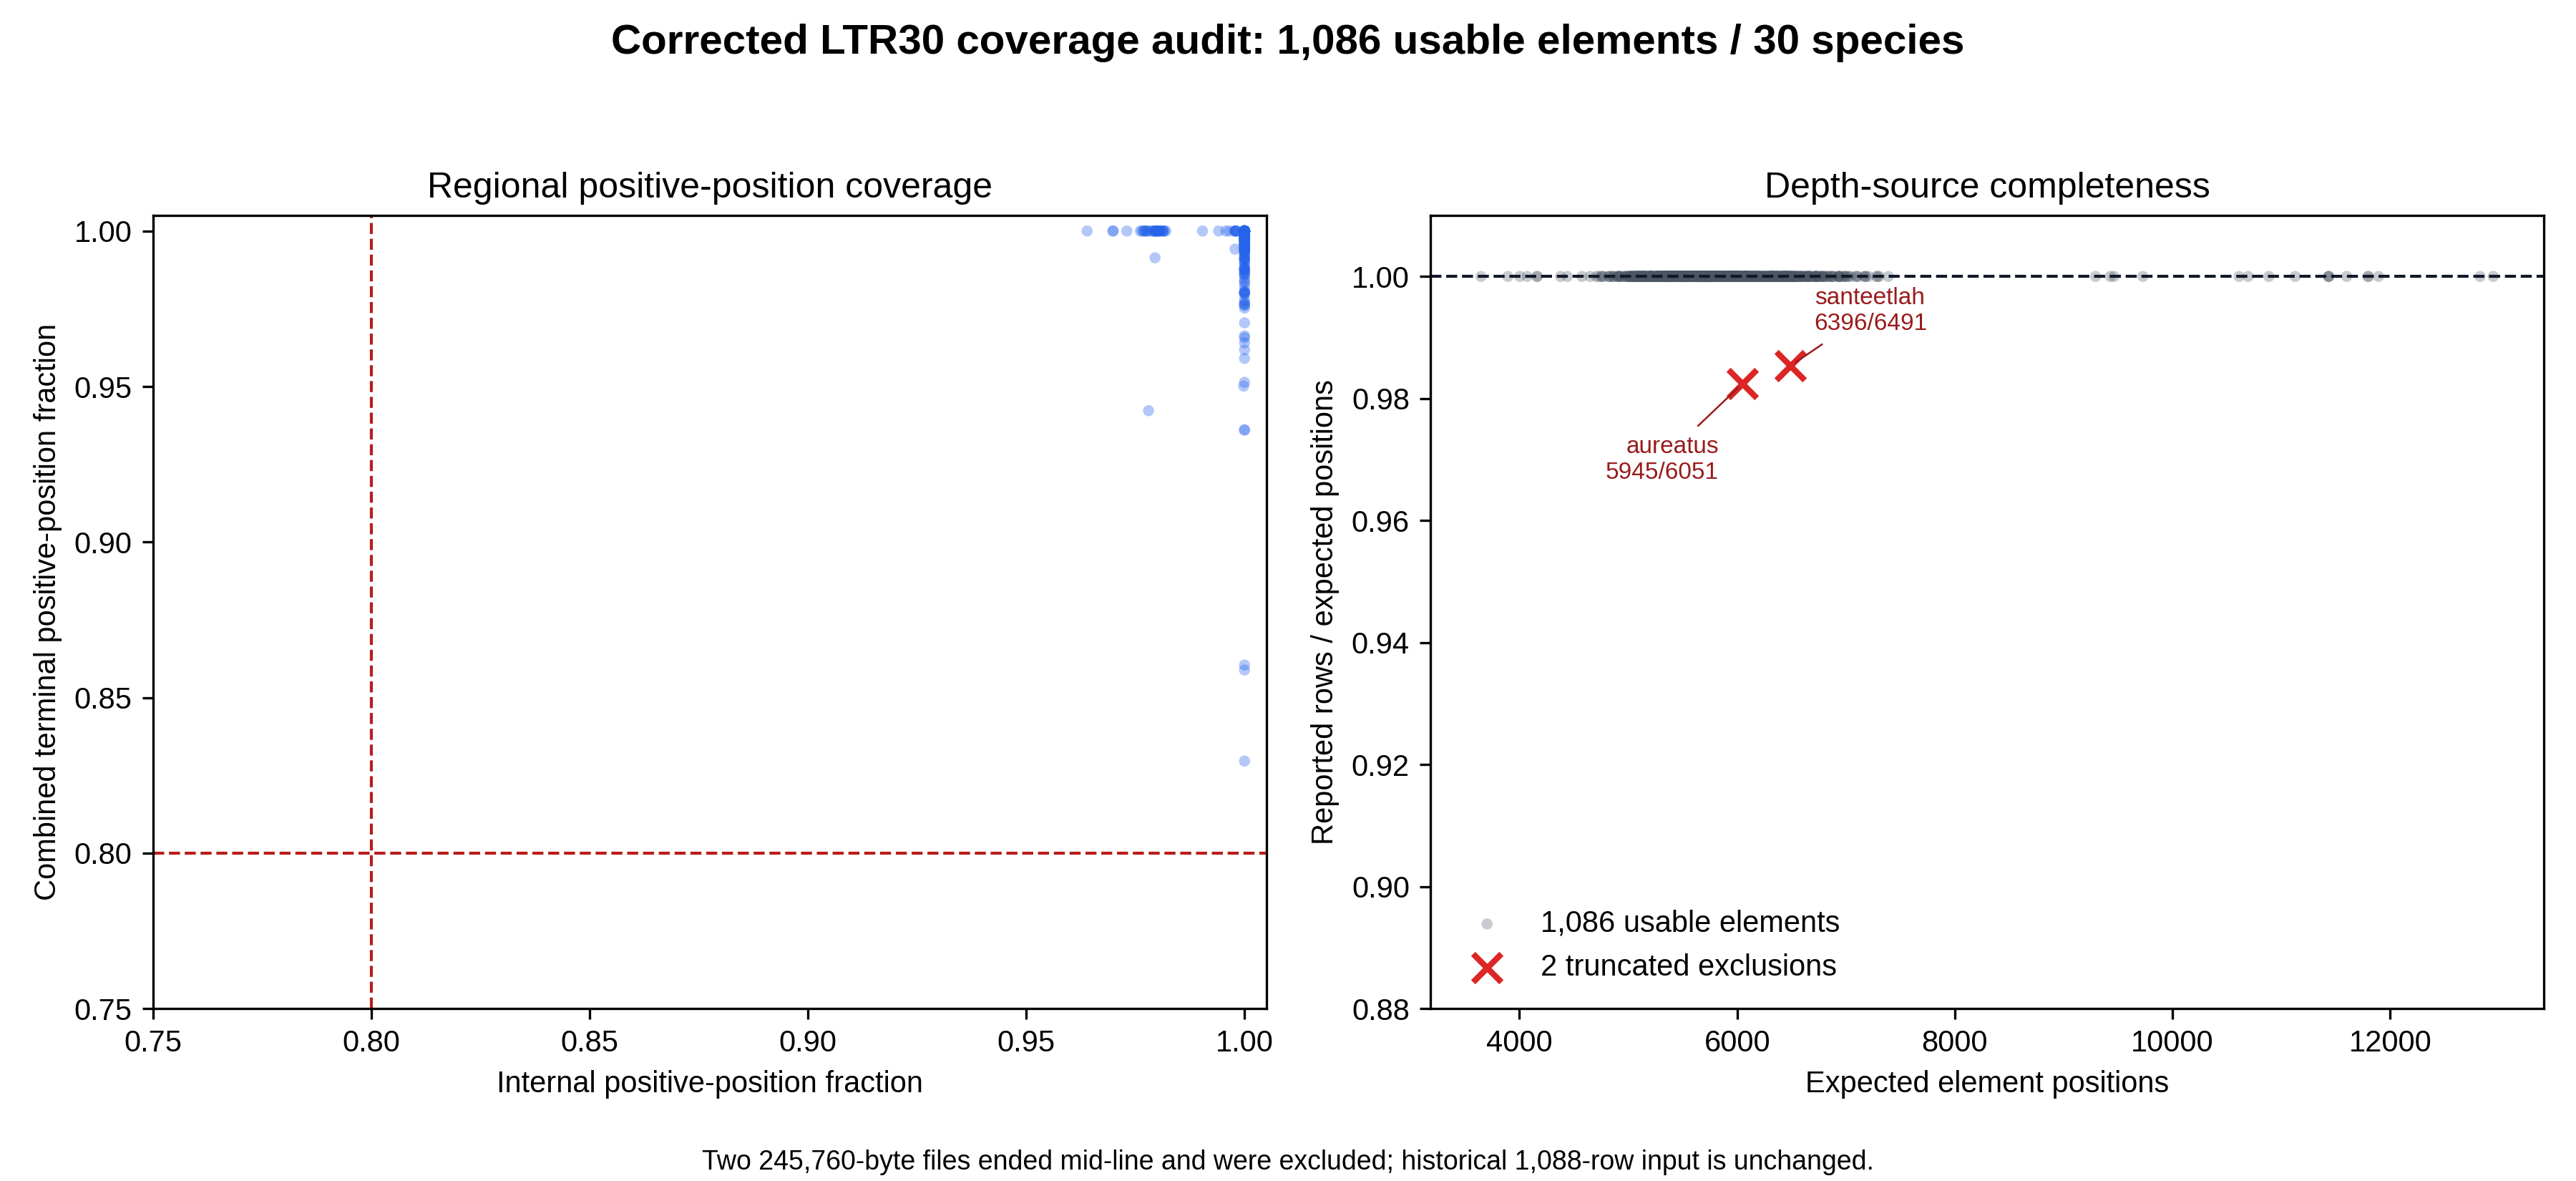

In [4]:
elements = read_csv("results/data/corrected/ectopic_ltr30/ectopic_element_metrics_ltr30_v1.csv")
robustness = read_csv("results/data/corrected/ectopic_ltr30/ectopic_species_robustness_ltr30_v1.csv")
excluded = read_csv("results/data/corrected/ectopic_ltr30/ectopic_excluded_elements_ltr30_v1.csv")
coverage = read_csv("results/data/corrected/ectopic_ltr30/ectopic_resource_coverage_ltr30_v1.csv")
ltr_manifest = json.loads(resolve_artifact(
    "results/data/corrected/ectopic_ltr30/ectopic_ltr30_v1.manifest.json"
).read_text())
vetted = read_csv("path_analysis/data/derived/panels/study_te_resource_panel34_v1.csv")
assert len(elements) == 1086 and elements.species.nunique() == 30
assert set(elements.species).issubset(set(vetted.species))
assert elements.source_depth_status.eq("usable").all()
assert elements.ratio_terminal_internal_all_positions.gt(0).all()
assert np.isfinite(elements.ratio_terminal_internal_all_positions).all()
assert len(excluded) == 2 and excluded.usable.eq(False).all()
assert ltr_manifest["n_selected_elements"] == 1088
assert ltr_manifest["n_usable_elements"] == 1086
assert ltr_manifest["n_source_corrupt_exclusions"] == 2
assert ltr_manifest["n_species_with_usable_elements"] == 30
support = elements.groupby("species", as_index=False).agg(
    n_elements=("element_id", "size"),
    median_terminal_internal=("ratio_terminal_internal_all_positions", "median"),
    mean_terminal_internal=("ratio_terminal_internal_all_positions", "mean"),
    median_reported_position_fraction=("reported_position_fraction", "median"),
)
assert support.species.nunique() == 30, support.species.nunique()
display(support.sort_values("median_terminal_internal"))
display(excluded[[
    "species", "element_id", "depth_file", "reported_position_fraction",
    "partial_final_line", "exclusion_reason", "input_modified",
]])
display(coverage.sort_values(["resource_status", "species"]))
display(robustness.sort_values(["analysis_branch", "species"]))
display(elements[[
    "species", "element_id", "Superfamily", "Complete", "domain_count",
    "mean_depth_terminal_all_positions", "mean_depth_internal_all_positions",
    "ratio_terminal_internal_all_positions", "reported_position_fraction",
    "terminal_positive_coverage_fraction", "internal_positive_coverage_fraction",
]].head(40))
show_figure("results/figures/corrected/ectopic_ltr30/ectopic_ltr30_coverage_qc_v1.png")

## Artifact-screened historical-style distribution

Jake's historical analysis intentionally prevented non-biological mapping
pileups from dictating the presentation scale. The corrected implementation keeps
the complete 1,086-element table unchanged and exports a separate row-level screen.
It flags one element only when all three conditions hold: it is above the
within-species 1.5-IQR upper fence, its left and right LTR depths differ by more
than 64-fold, and it contributes over half of its species' summed ratio. This
retains 1,085 elements and all 30 species. It is not blanket IQR pruning.

,species,element_id,ratio_terminal_internal_all_positions,left_right_terminal_log2_imbalance,species_iqr_upper,fraction_of_species_ratio_sum,artifact_screen_reason
515,intermedius,JAUEJH010597481.1_De_5169_11831,56.066203,7.0375,1.341768,0.75019,flagged: upper 1.5-IQR outlier; >64-fold left/right terminal imbalance; >50% of species ratio sum


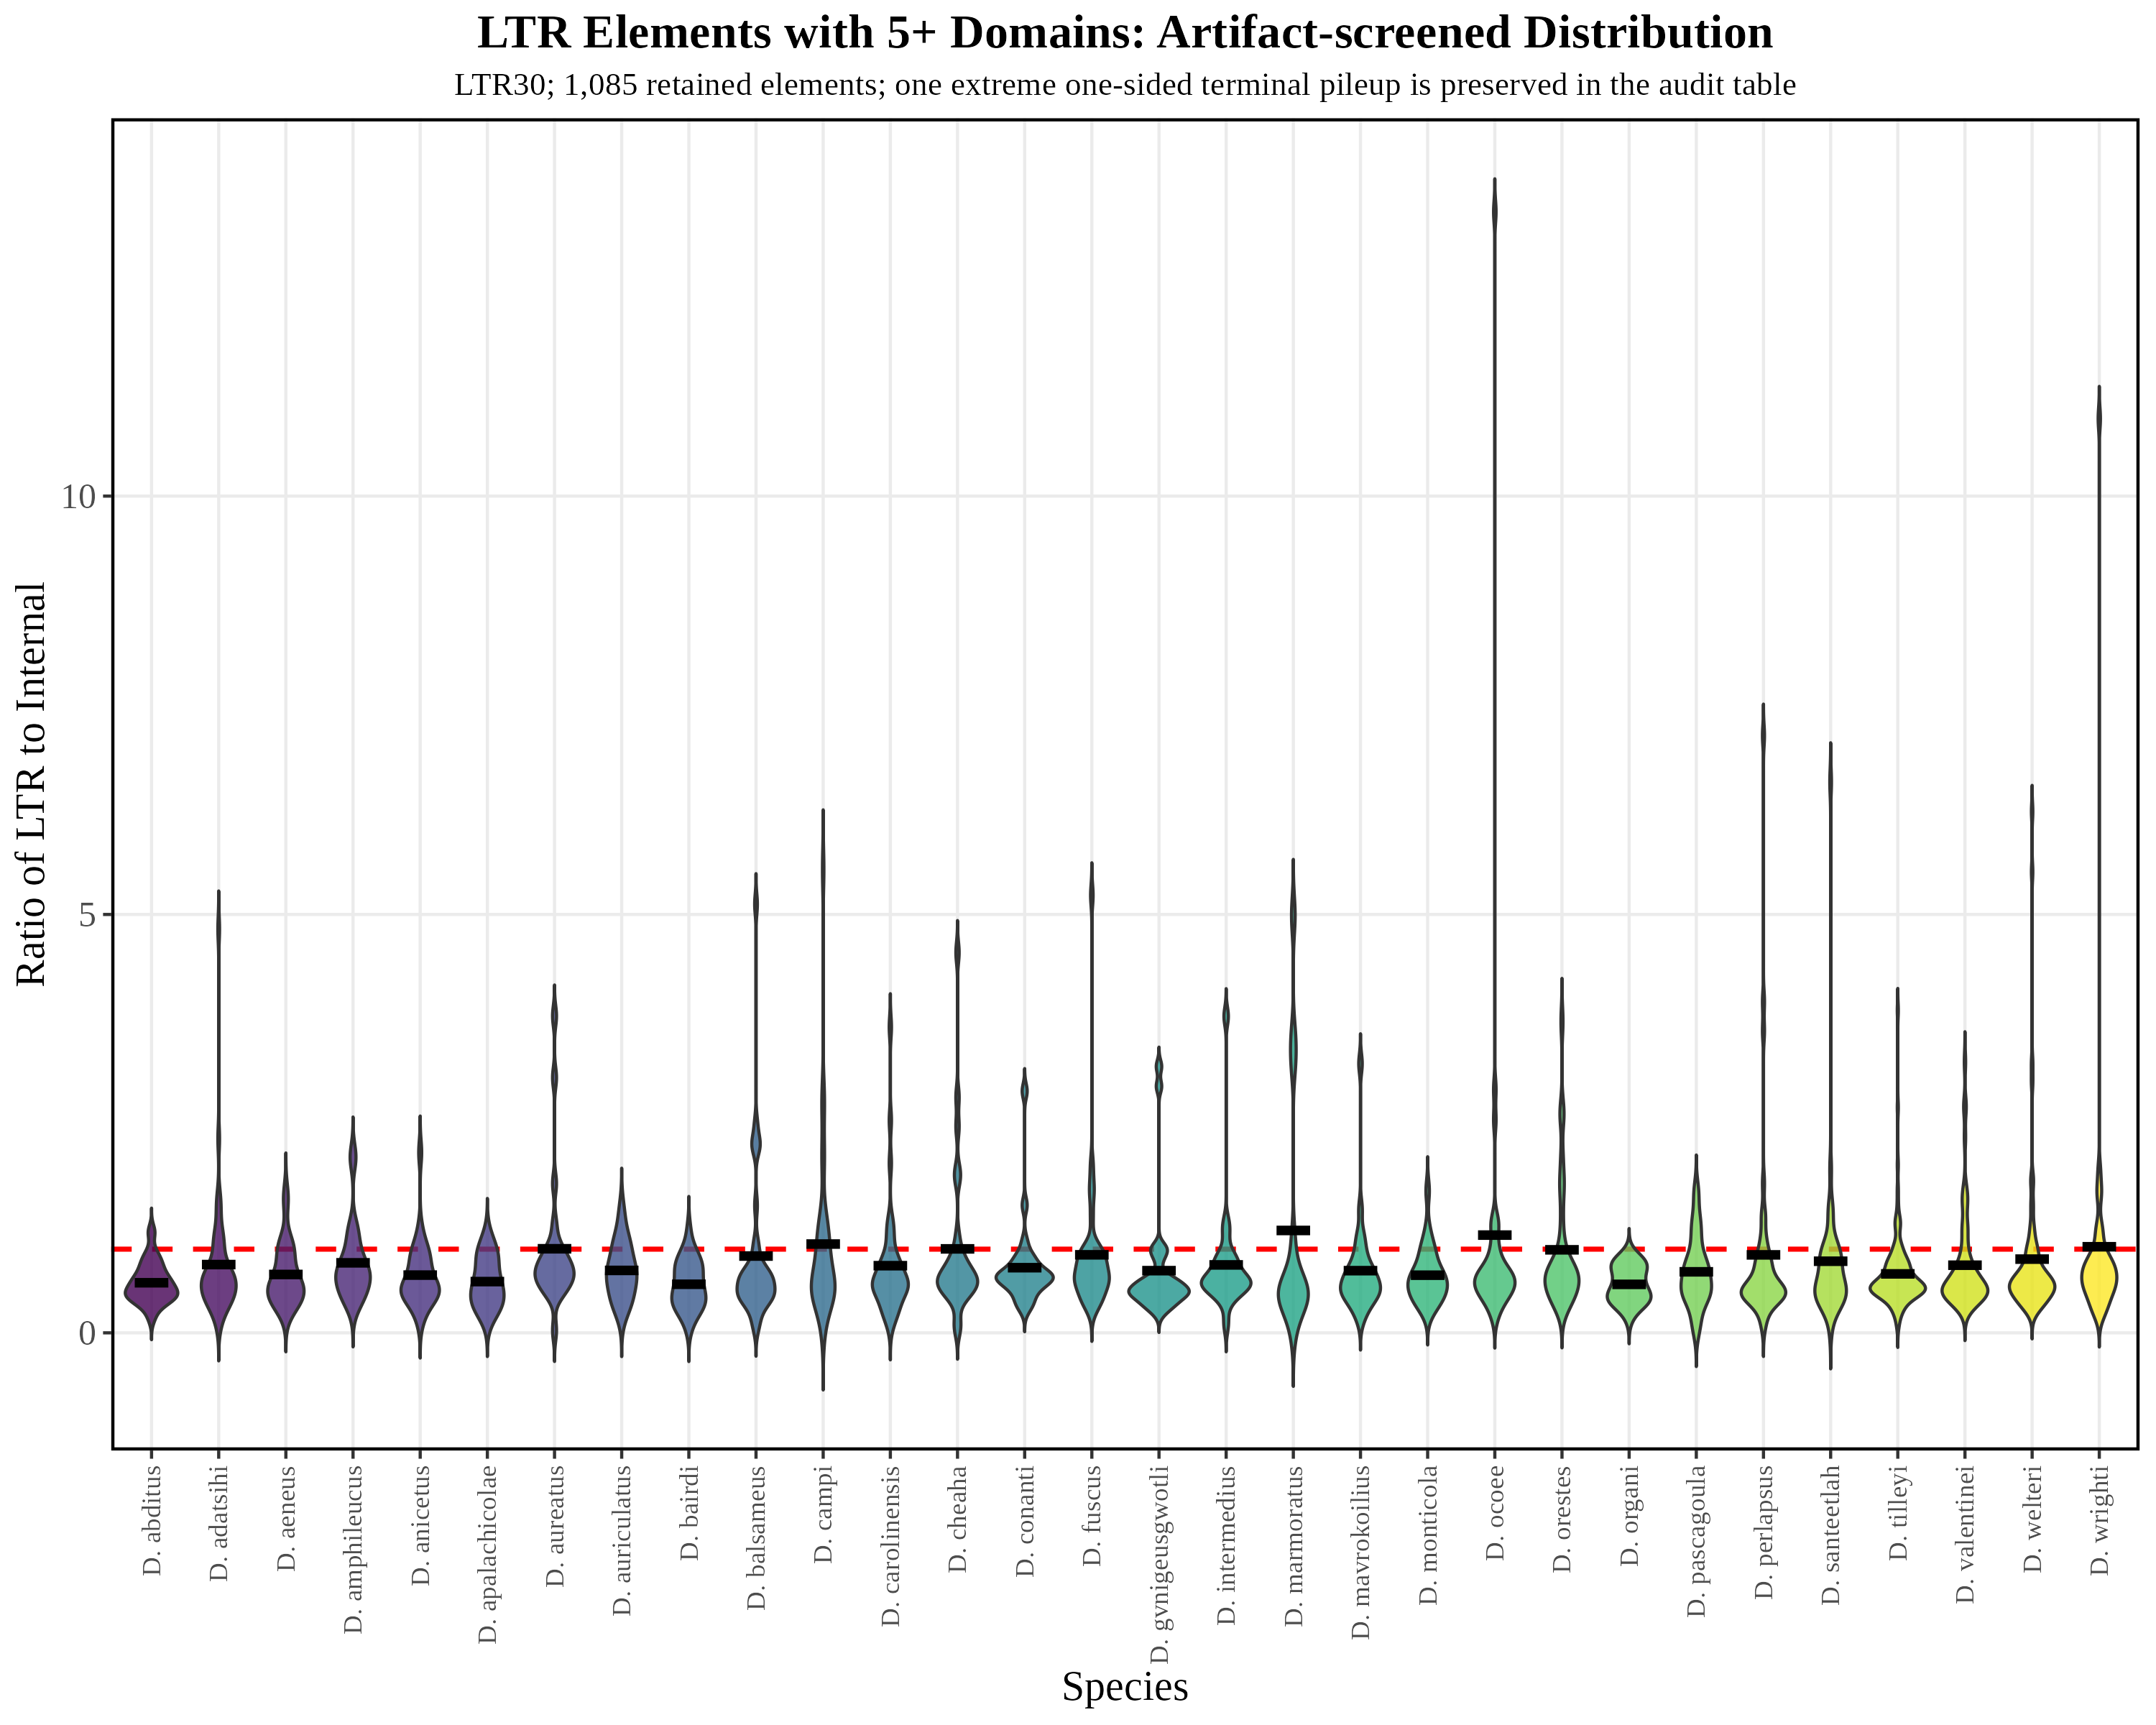

In [5]:
artifact_screen = read_csv("results/data/research_review/ltr_mapping_artifact_screen_ltr30_v1.csv")
flagged_mapping_artifacts = artifact_screen.query("artifact_screen_keep == False")
assert len(artifact_screen) == 1086
assert artifact_screen.artifact_screen_keep.sum() == 1085
assert artifact_screen.query("artifact_screen_keep == True").species.nunique() == 30
assert flagged_mapping_artifacts.element_id.tolist() == ["JAUEJH010597481.1_De_5169_11831"]
display(flagged_mapping_artifacts[[
    "species", "element_id", "ratio_terminal_internal_all_positions",
    "left_right_terminal_log2_imbalance", "species_iqr_upper",
    "fraction_of_species_ratio_sum", "artifact_screen_reason",
]])
show_figure("results/figures/research_review/ltr_terminal_internal_artifact_screened_ltr30_v1.png")

## Robust distribution and correctly labeled tests

The unfiltered audit is retained below, followed by the log view. The report prints
raw, log10, and Kruskal-Wallis results for both the complete and artifact-screened
branches. These tests are not interchangeable. The log view exposes skew and
leverage that a raw violin can hide; species-level sample counts remain visible.
The exact report labels are `raw one-way ANOVA`, `log10 one-way ANOVA`, and
`Kruskal-Wallis raw`, with parallel artifact-screened labels.

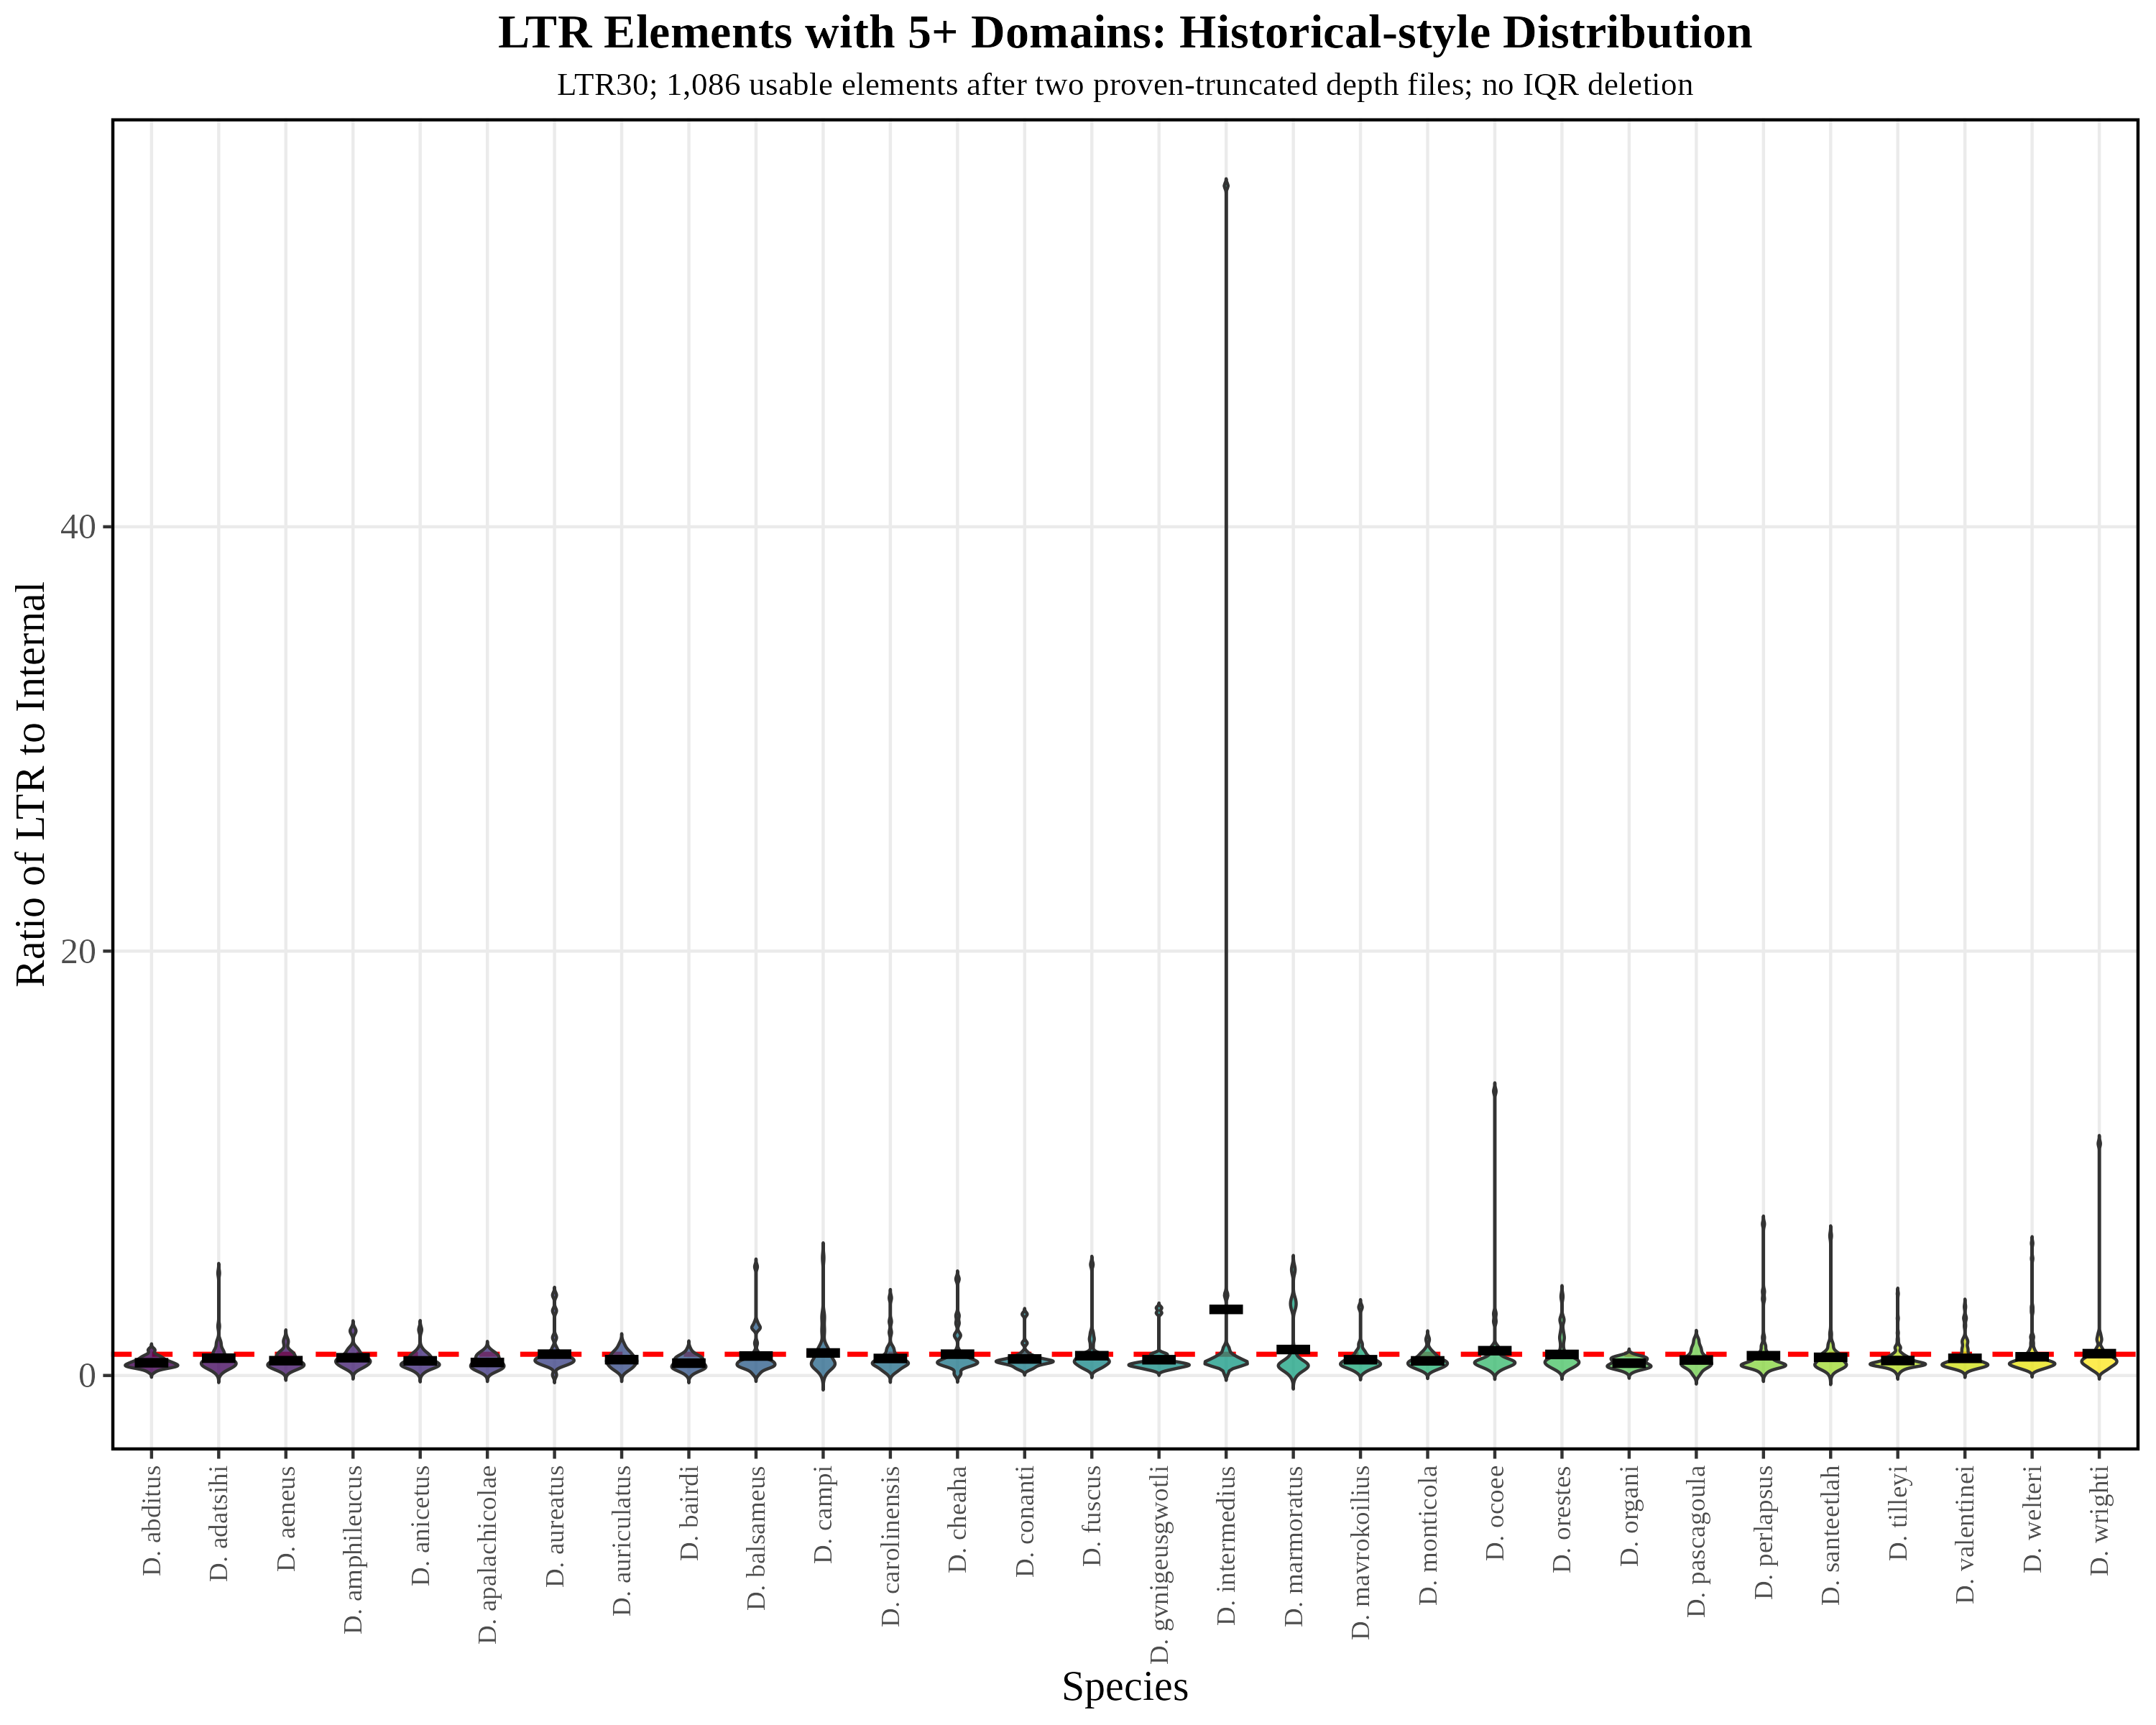

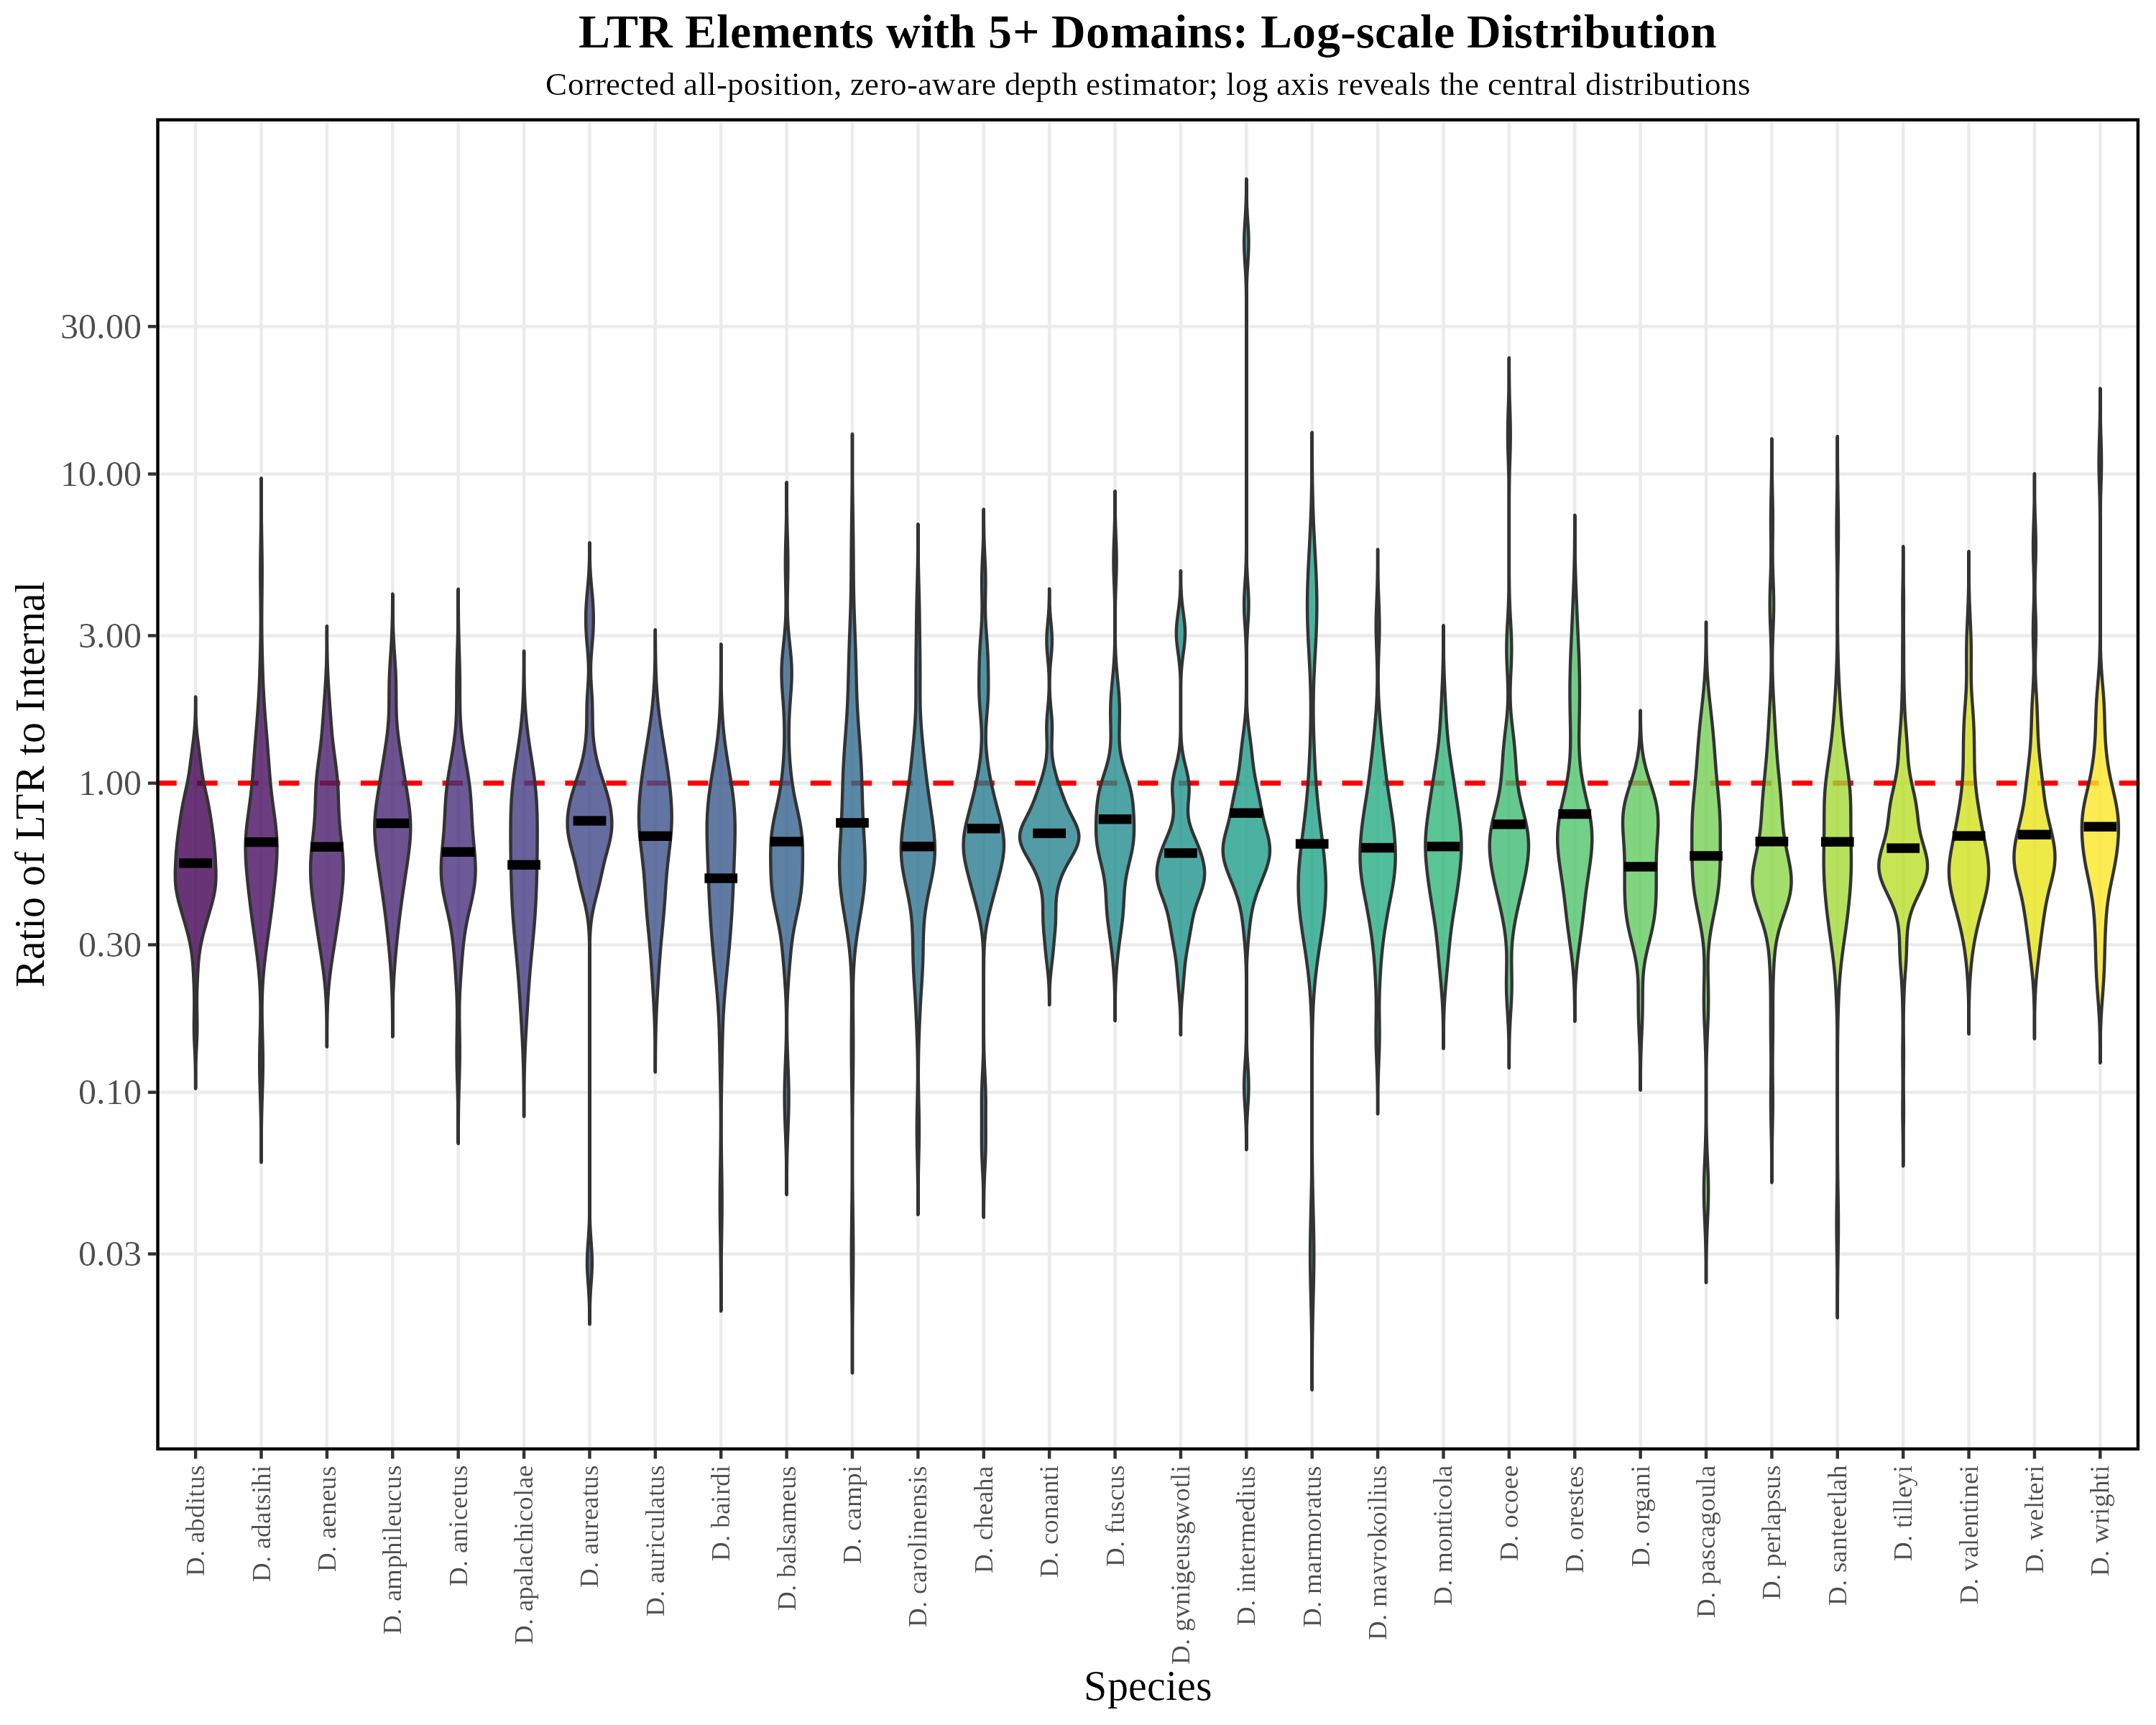

```text
LTR terminal:internal depth-ratio statistics
Analysis scope: LTR30 audited TE-resource subset with available >=3-kb, >=5-domain elements
Elements: 1086
Species: 30
Selected elements: 1,088; exclusions: 2 depth files proven truncated mid-final-line; usable elements: 1,086
Unfiltered positive finite element audit: 1,086 elements after two source-corrupt exclusions; NO IQR deletion.
Artifact-screened presentation: 1,085 retained elements. It does not apply blanket IQR deletion.
Screen rule: flag only elements that are simultaneously an upper within-species 1.5-IQR outlier, have absolute left/right terminal log2 imbalance > 6 (>64-fold), and contribute >50% of the species ratio sum.
Flagged element: JAUEJH010597481.1_De_5169_11831; corrected ratio = 56.0662; left/right log2 imbalance = 7.0375
Estimator: mean terminal depth across all expected positions / mean internal depth across all expected positions; explicit zero-depth positions are retained.
Interpretation caveat: terminal:internal depth is a deletion footprint proxy, not a directly validated ectopic-recombination rate.

Raw one-way ANOVA: ratio_terminal_internal ~ species
              Df Sum Sq Mean Sq F value Pr(>F)  
species       29    149   5.130   1.461 0.0553 .
Residuals   1056   3707   3.511                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Log10 one-way ANOVA: log10(ratio_terminal_internal) ~ species
              Df Sum Sq Mean Sq F value Pr(>F)
species       29   2.52 0.08690   1.067  0.371
Residuals   1056  86.01 0.08144               

Kruskal-Wallis raw ratio: ratio_terminal_internal ~ species

	Kruskal-Wallis rank sum test

data:  ratio_terminal_internal by species
Kruskal-Wallis chi-squared = 35.13, df = 29, p-value = 0.2003


Artifact-screened raw one-way ANOVA: ratio_terminal_internal ~ species
              Df Sum Sq Mean Sq F value Pr(>F)
species       29   25.3  0.8721   1.177  0.238
Residuals   1055  781.5  0.7408               

Artifact-screened log10 one-way ANOVA: log10(ratio_terminal_internal) ~ species
              Df Sum Sq Mean Sq F value Pr(>F)
species       29   2.32 0.08006   1.024  0.431
Residuals   1055  82.45 0.07815               

Artifact-screened Kruskal-Wallis raw ratio: ratio_terminal_internal ~ species

	Kruskal-Wallis rank sum test

data:  ratio_terminal_internal by species
Kruskal-Wallis chi-squared = 34.673, df = 29, p-value = 0.2155


Tukey HSD after raw one-way ANOVA
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = ratio_terminal_internal ~ species, data = ltr)

$species
                                      diff         lwr         upr     p adj
adatsihi-abditus              0.2173577190 -1.10175961  1.53647505 1.0000000
aeneus-abditus                0.0990709900 -1.46618276  1.66432474 1.0000000
amphileucus-abditus           0.2382237172 -1.37330365  1.84975109 1.0000000
anicetus-abditus              0.0914848676 -1.49618416  1.67915390 1.0000000
apalachicolae-abditus         0.0139763189 -2.16476470  2.19271733 1.0000000
aureatus-abditus              0.4062381909 -1.25796944  2.07044582 1.0000000
auriculatus-abditus           0.1475872785 -1.95690341  2.25207797 1.0000000
bairdi-abditus               -0.0179449700 -1.48862769  1.45273775 1.0000000
balsameus-abditus             0.3192927379 -1.12004999  1.75863547 1.0000000
campi-abditus                 0.4625940074 -0.99202820  1.91721621 0.9999980
carolinensis-abditus          0.2039596065 -1.19367903  1.60159825 1.0000000
cheaha-abditus                0.4050508081 -1.16020294  1.97030456 1.0000000
conanti-abditus               0.1800288312 -1.43149854  1.79155620 1.0000000
fuscus-abditus                0.3339493000 -1.10539343  1.77329203 1.0000000
gvnigeusgwotli-abditus        0.1446042074 -1.42064954  1.70985796 1.0000000
intermedius-abditus           2.5156533227  0.87867177  4.15263488 0.0000043
marmoratus-abditus            0.6251037153 -1.41359262  2.66380005 0.9999991
mavrokoilius-abditus          0.1445028716 -1.42075088  1.70975662 1.0000000
monticola-abditus             0.0904648975 -1.54651666  1.72744645 1.0000000
ocoee-abditus                 0.5697146190 -0.86962811  2.00905735 0.9998187
orestes-abditus               0.3937629973 -1.07691973  1.86444572 1.0000000
organi-abditus               -0.0190043602 -1.74382999  1.70582127 1.0000000
pascagoula-abditus            0.1308307791 -1.74824085  2.00990241 1.0000000
perlapsus-abditus             0.3333543256 -0.98576300  1.65247166 1.0000000
santeetlah-abditus            0.2572713331 -1.07174823  1.58629089 1.0000000
tilleyi-abditus               0.1060885957 -0.90344985  1.11562704 1.0000000
valentinei-abditus            0.2098832788 -0.93957764  1.35934420 1.0000000
welteri-abditus               0.2825472410 -0.84231098  1.40740546 1.0000000
wrighti-abditus               0.4303284984 -0.95462898  1.81528598 0.9999988
aeneus-adatsihi              -0.1182867290 -1.84022755  1.60365409 1.0000000
amphileucus-adatsihi          0.0208659982 -1.74324322  1.78497522 1.0000000
anicetus-adatsihi            -0.1258728513 -1.86821433  1.61646862 1.0000000
apalachicolae-adatsihi       -0.2033814001 -2.49728054  2.09051774 1.0000000
aureatus-adatsihi             0.1888804719 -1.62347929  2.00124024 1.0000000
auriculatus-adatsihi         -0.0697704405 -2.29326812  2.15372724 1.0000000
bairdi-adatsihi              -0.2353026890 -1.87175267  1.40114729 1.0000000
balsameus-adatsihi            0.1019350190 -1.50640835  1.71027838 1.0000000
campi-adatsihi                0.2452362884 -1.37679535  1.86726793 1.0000000
carolinensis-adatsihi        -0.0133981125 -1.58452976  1.55773353 1.0000000
cheaha-adatsihi               0.1876930891 -1.53424773  1.90963391 1.0000000
conanti-adatsihi             -0.0373288878 -1.80143811  1.72678033 1.0000000
fuscus-adatsihi               0.1165915811 -1.49175178  1.72493495 1.0000000
gvnigeusgwotli-adatsihi      -0.0727535116 -1.79469433  1.64918731 1.0000000
intermedius-adatsihi          2.2982956037  0.51090379  4.08568742 0.0006073
marmoratus-adatsihi           0.4077459964 -1.75358314  2.56907513 1.0000000
mavrokoilius-adatsihi        -0.0728548474 -1.79479567  1.64908597 1.0000000
monticola-adatsihi           -0.1268928214 -1.91428463  1.66049899 1.0000000
ocoee-adatsihi                0.3523569001 -1.25598646  1.96070027 1.0000000
orestes-adatsihi              0.1764052783 -1.46004470  1.81285526 1.0000000
organi-adatsihi              -0.2363620792 -2.10453882  1.63181466 1.0000000
pascagoula-adatsihi          -0.0865269399 -2.09798687  1.92493299 1.0000000
perlapsus-adatsihi            0.1159966067 -1.38571289  1.61770610 1.0000000
santeetlah-adatsihi           0.0399136141 -1.47050152  1.55032874 1.0000000
tilleyi-adatsihi             -0.1112691233 -1.34990900  1.12737075 1.0000000
valentinei-adatsihi          -0.0074744402 -1.36258377  1.34763489 1.0000000
welteri-adatsihi              0.0651895220 -1.26911438  1.39949342 1.0000000
wrighti-adatsihi              0.2129707795 -1.34689078  1.77283234 1.0000000
amphileucus-aeneus            0.1391527272 -1.81584858  2.09415404 1.0000000
anicetus-aeneus              -0.0075861224 -1.94296789  1.92779565 1.0000000
apalachicolae-aeneus         -0.0850946711 -2.52884631  2.35865697 1.0000000
aureatus-aeneus               0.3071672009 -1.69148152  2.30581592 1.0000000
auriculatus-aeneus            0.0485162884 -2.32927485  2.42630743 1.0000000
bairdi-aeneus                -0.1170159600 -1.95764556  1.72361364 1.0000000
balsameus-aeneus              0.2202217479 -1.59546467  2.03590816 1.0000000
campi-aeneus                  0.3635230173 -1.46429957  2.19134561 1.0000000
carolinensis-aeneus           0.1048886165 -1.67791912  1.88769635 1.0000000
cheaha-aeneus                 0.3059798181 -1.61105669  2.22301632 1.0000000
conanti-aeneus                0.0809578412 -1.87404347  2.03595915 1.0000000
fuscus-aeneus                 0.2348783100 -1.58080810  2.05056472 1.0000000
gvnigeusgwotli-aeneus         0.0455332174 -1.87150329  1.96256972 1.0000000
intermedius-aeneus            2.4165823327  0.44054633  4.39261833 0.0018155
marmoratus-aeneus             0.5260327253 -1.79372856  2.84579401 1.0000000
mavrokoilius-aeneus           0.0454318815 -1.87160462  1.96246839 1.0000000
monticola-aeneus             -0.0086060925 -1.98464209  1.96742991 1.0000000
ocoee-aeneus                  0.4706436290 -1.34504279  2.28633004 1.0000000
orestes-aeneus                0.2946920073 -1.54593759  2.13532161 1.0000000
organi-aeneus                -0.1180753502 -2.16747358  1.93132288 1.0000000
pascagoula-aeneus             0.0317597891 -2.14904736  2.21256694 1.0000000
perlapsus-aeneus              0.2342833356 -1.48765748  1.95622415 1.0000000
santeetlah-aeneus             0.1582003431 -1.57133793  1.88773862 1.0000000
tilleyi-aeneus                0.0070176057 -1.49104031  1.50507552 1.0000000
valentinei-aeneus             0.1108122888 -1.48489134  1.70651592 1.0000000
welteri-aeneus                0.1834762510 -1.39459716  1.76154966 1.0000000
wrighti-aeneus                0.3312575084 -1.44162627  2.10414128 1.0000000
anicetus-amphileucus         -0.1467388495 -2.11973245  1.82625475 1.0000000
apalachicolae-amphileucus    -0.2242473983 -2.69789313  2.24939834 1.0000000
aureatus-amphileucus          0.1680144737 -1.86707713  2.20310608 1.0000000
auriculatus-amphileucus      -0.0906364387 -2.49914051  2.31786763 1.0000000
bairdi-amphileucus           -0.2561686872 -2.13630658  1.62396920 1.0000000
balsameus-amphileucus         0.0810690208 -1.77465680  1.93679484 1.0000000
campi-amphileucus             0.2243702902 -1.64323153  2.09197212 1.0000000
carolinensis-amphileucus     -0.0342641107 -1.85783330  1.78930508 1.0000000
cheaha-amphileucus            0.1668270909 -1.78817422  2.12182840 1.0000000
conanti-amphileucus          -0.0581948860 -2.05043766  1.93404789 1.0000000
fuscus-amphileucus            0.0957255829 -1.76000024  1.95145140 1.0000000
gvnigeusgwotli-amphileucus   -0.0936195098 -2.04862082  1.86138180 1.0000000
intermedius-amphileucus       2.2774296055  0.26454128  4.29031794 0.0079318
marmoratus-amphileucus        0.3868799982 -1.96435235  2.73811235 1.0000000
mavrokoilius-amphileucus     -0.0937208456 -2.04872215  1.86128046 1.0000000
monticola-amphileucus        -0.1477588196 -2.16064715  1.86512951 1.0000000
ocoee-amphileucus             0.3314909019 -1.52423492  2.18721672 1.0000000
orestes-amphileucus           0.1555392801 -1.72459861  2.03567717 1.0000000
organi-amphileucus           -0.2572280774 -2.34218234  1.82772618 1.0000000
pascagoula-amphileucus       -0.1073929381 -2.32164699  2.10686111 1.0000000
perlapsus-amphileucus         0.0951306085 -1.66897861  1.85923983 1.0000000
santeetlah-amphileucus        0.0190476159 -1.75247822  1.79057346 1.0000000
tilleyi-amphileucus          -0.1321351215 -1.67847877  1.41420853 1.0000000
valentinei-amphileucus       -0.0283404384 -1.66945933  1.61277846 1.0000000
welteri-amphileucus           0.0443235238 -1.57965826  1.66830531 1.0000000
wrighti-amphileucus           0.1921047813 -1.62176347  2.00597303 1.0000000
apalachicolae-anicetus       -0.0775085488 -2.53567772  2.38066063 1.0000000
aureatus-anicetus             0.3147533232 -1.70149823  2.33100488 1.0000000
auriculatus-anicetus          0.0561024108 -2.33650377  2.44870859 1.0000000
bairdi-anicetus              -0.1094298377 -1.96915857  1.75029889 1.0000000
balsameus-anicetus            0.2278078703 -1.60723730  2.06285304 1.0000000
campi-anicetus                0.3711091397 -1.47594502  2.21816330 1.0000000
carolinensis-anicetus         0.1124747388 -1.69004490  1.91499438 1.0000000
cheaha-anicetus               0.3135659404 -1.62181583  2.24894771 1.0000000
conanti-anicetus              0.0885439636 -1.88444964  2.06153757 1.0000000
fuscus-anicetus               0.2424644324 -1.59258074  2.07750961 1.0000000
gvnigeusgwotli-anicetus       0.0531193398 -1.88226243  1.98850111 1.0000000
intermedius-anicetus          2.4241684551  0.43032997  4.41800694 0.0020465
marmoratus-anicetus           0.5336188477 -1.80132570  2.86856340 1.0000000
mavrokoilius-anicetus         0.0530180039 -1.88236377  1.98839977 1.0000000
monticola-anicetus           -0.0010199701 -1.99485846  1.99281852 1.0000000
ocoee-anicetus                0.4782297514 -1.35681542  2.31327493 1.0000000
orestes-anicetus              0.3022781296 -1.55745060  2.16200686 1.0000000
organi-anicetus              -0.1104892278 -2.17705806  1.95607960 1.0000000
pascagoula-anicetus           0.0393459114 -2.15760504  2.23629686 1.0000000
perlapsus-anicetus            0.2418694580 -1.50047202  1.98421093 1.0000000
santeetlah-anicetus           0.1657864654 -1.58406389  1.91563682 1.0000000
tilleyi-anicetus              0.0146037280 -1.50685976  1.53606722 1.0000000
valentinei-anicetus           0.1183984112 -1.49929862  1.73609545 1.0000000
welteri-anicetus              0.1910623734 -1.40924676  1.79137150 1.0000000
wrighti-anicetus              0.3388436308 -1.45386117  2.13154843 1.0000000
aureatus-apalachicolae        0.3922618720 -2.11602236  2.90054611 1.0000000
auriculatus-apalachicolae     0.1336109596 -2.68610247  2.95332439 1.0000000
bairdi-apalachicolae         -0.0319212889 -2.41620534  2.35236276 1.0000000
balsameus-apalachicolae       0.3053164191 -2.05976503  2.67039787 1.0000000
campi-apalachicolae           0.4486176885 -1.92579351  2.82302888 1.0000000
carolinensis-apalachicolae    0.1899832876 -2.14995187  2.52991844 1.0000000
cheaha-apalachicolae          0.3910744892 -2.05267715  2.83482613 1.0000000
conanti-apalachicolae         0.1660525123 -2.30759322  2.63969825 1.0000000
fuscus-apalachicolae          0.3199729812 -2.04510847  2.68505443 1.0000000
gvnigeusgwotli-apalachicolae  0.1306278885 -2.31312375  2.57437953 1.0000000
intermedius-apalachicolae     2.5016770038  0.01137353  4.99198047 0.0471848
marmoratus-apalachicolae      0.6111273965 -2.15982650  3.38208129 1.0000000
mavrokoilius-apalachicolae    0.1305265527 -2.31322508  2.57427819 1.0000000
monticola-apalachicolae       0.0764885787 -2.41381489  2.56679205 1.0000000
ocoee-apalachicolae           0.5557383002 -1.80934315  2.92081975 1.0000000
orestes-apalachicolae         0.3797866784 -2.00449737  2.76407073 1.0000000
organi-apalachicolae         -0.0329806791 -2.58188754  2.51592618 1.0000000
pascagoula-apalachicolae      0.1168544602 -2.53885880  2.77256772 1.0000000
perlapsus-apalachicolae       0.3193780068 -1.97452114  2.61327715 1.0000000
santeetlah-apalachicolae      0.2432950142 -2.05631272  2.54290275 1.0000000
tilleyi-apalachicolae         0.0921122768 -2.03886652  2.22309107 1.0000000
valentinei-apalachicolae      0.1959069599 -2.00481182  2.39662574 1.0000000
welteri-apalachicolae         0.2685709221 -1.91939818  2.45654002 1.0000000
wrighti-apalachicolae         0.4163521796 -1.91603072  2.74873508 1.0000000
auriculatus-aureatus         -0.2586509124 -2.70271688  2.18541505 1.0000000
bairdi-aureatus              -0.4241831609 -2.34966623  1.50129991 1.0000000
balsameus-aureatus           -0.0869454529 -1.98859865  1.81470775 1.0000000
campi-aureatus                0.0563558165 -1.85688833  1.96959996 1.0000000
carolinensis-aureatus        -0.2022785844 -2.07256497  1.66800780 1.0000000
cheaha-aureatus              -0.0011873828 -1.99983610  1.99746133 1.0000000
conanti-aureatus             -0.2262093597 -2.26130097  1.80888225 1.0000000
fuscus-aureatus              -0.0722888908 -1.97394209  1.82936431 1.0000000
gvnigeusgwotli-aureatus      -0.2616339835 -2.26028270  1.73701473 1.0000000
intermedius-aureatus          2.1094151318  0.05410834  4.16472192 0.0355770
marmoratus-aureatus           0.2188655244 -2.16878188  2.60651293 1.0000000
mavrokoilius-aureatus        -0.2617353193 -2.26038404  1.73691340 1.0000000
monticola-aureatus           -0.3157732933 -2.37108008  1.73953350 1.0000000
ocoee-aureatus                0.1634764282 -1.73817677  2.06512963 1.0000000
ores
... [display truncated; open the linked source for the complete file]
```

In [6]:
show_figure("results/figures/research_review/ltr_terminal_internal_violin_ltr30_v1.png")
show_figure("results/figures/research_review/ltr_terminal_internal_log_ltr30_v1.png")
show_text("results/data/research_review/ltr_terminal_internal_stats_v1.txt")

## Interpretation and review boundary

- State the number of species and eligible elements with every result.
- Use element-level distributions plus species support; do not infer equal
  precision from unequal element counts.
- Element rows are nested within species. The three omnibus tests are descriptive
  diagnostics, not 1,086 independent biological replicates or a substitute for a
  hierarchical species/family model.
- The two truncated source files are excluded without repair or imputation; the
  exact file hashes and exclusion reasons remain in the audit table.
- The one mapping-artifact candidate is excluded only from the screened
  presentation/sensitivity branch. Its complete corrected row remains in the
  unfiltered audit table and raw/log companion figures.
- The raw ANOVA is the historically used descriptive test. The log-scale ANOVA
  and rank-based Kruskal-Wallis result are robust companions, not relabeled raw
  results.
- A terminal:internal depth ratio is mechanistically suggestive, but it does not
  by itself measure the rate of ectopic recombination.